In [1]:
%matplotlib inline
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
from matplotlib.widgets import Slider
from matplotlib.contour import ContourSet

import numpy as np
import h5py
import sys
sys.path.append('../src/')
import plot_config
import data_ios 
from config import DATA_PATH, TEMP_DATA_PATH, FIGURES_PATH


In [12]:
def visualize_4d_contour(
    data1: np.ndarray,
    data2: np.ndarray,
    data3: np.ndarray,
    axis: int = 2,
    cmaps: tuple = ("viridis", "plasma", "cividis"),
    levels: int = 20,
    filled: bool = True,
    titles: tuple = ("Field 1", "Field 2", "Field 3"),
    coord_range: tuple = (-1.0, 1.0),
):
    """
    Visualize three (T, N, N, N) arrays as side-by-side 2D contour plots
    over time, with a single shared slider to scrub the T dimension.

    The spatial mean is taken along `axis` (0-indexed into the three spatial
    axes 1-3) to collapse each array to shape (T, N, N).

    Subplots share the y-axis. Each subplot has its own colorbar and title.
    Axis labels are "x / r200c" and "y / r200c".

    Parameters
    ----------
    data1, data2, data3 : np.ndarray, shape (T, N, N, N)
        The three 4-D fields to display.
    axis        : int   – spatial axis to average over (0, 1, or 2). Default 2.
    cmaps       : 3-tuple of colormap names, one per subplot.
    levels      : number of contour levels. Default 20.
    filled      : True → contourf (filled), False → contour (lines only).
    titles      : 3-tuple of subplot titles.
    coord_range : (min, max) extent along both spatial axes, in units of r200c.
                  Default (-1, 1) so ticks run from -1 to 1 r200c.
    """
    datasets = (data1, data2, data3)
    for i, d in enumerate(datasets):
        if d.ndim != 4:
            raise ValueError(f"data{i+1} must be 4-D, got shape {d.shape}")
    shapes = [d.shape for d in datasets]
    if len(set(shapes)) != 1:
        raise ValueError(f"All three arrays must share the same shape. Got {shapes}")

    T = data1.shape[0]
    spatial_axis = axis + 1

    # Reduce each dataset: (T, N, N, N) → (T, N, N)
    reduced = [d.mean(axis=spatial_axis) for d in datasets]

    # Fixed colorbar limits for each subplot
    vlims = [(5, 14), (5, 14), (-1, 1)]
    # Pre-compute explicit level arrays so colorbars span exactly vmin→vmax
    level_arrays = [np.linspace(vmin, vmax, levels + 1) for (vmin, vmax) in vlims]

    Ny, Nx = reduced[0].shape[1], reduced[0].shape[2]
    x_lin = np.linspace(coord_range[0], coord_range[1], Nx)
    y_lin = np.linspace(coord_range[0], coord_range[1], Ny)
    X, Y = np.meshgrid(x_lin, y_lin)

    # ── layout ────────────────────────────────────────────────────────────────
    #   Row 0  : three contour subplots (tall)
    #   Row 1  : single time slider     (thin)
    fig = plt.figure(figsize=(16, 6))
    gs = gridspec.GridSpec(
        2, 3,
        height_ratios=[18, 1],
        hspace=0.45,
        wspace=0.08,
    )

    axes = []
    for col in range(3):
        if col == 0:
            ax = fig.add_subplot(gs[0, col])
        else:
            ax = fig.add_subplot(gs[0, col], sharey=axes[0])
            ax.tick_params(labelleft=False)
        axes.append(ax)

    # Single slider spanning all three columns
    ax_slider = fig.add_subplot(gs[1, :])
    suptitle = fig.suptitle("Halo 21537, snapshot = 0", fontsize=14, fontweight="bold")
    plot_fn_name = "contourf" if filled else "contour"

    # ── draw initial frame (t=0) ──────────────────────────────────────────────
    cbars = []

    for col, (ax, red, lvls, (vmin, vmax), cmap, ttl) in enumerate(
        zip(axes, reduced, level_arrays, vlims, cmaps, titles)
    ):
        plot_fn = getattr(ax, plot_fn_name)
        cs = plot_fn(X, Y, red[0], levels=lvls, vmin=vmin, vmax=vmax, cmap=cmap,
                     extend="both")

        cbar = fig.colorbar(cs, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)
        cbars.append(cbar)

        ax.set_title(ttl, fontsize=12, fontweight="bold", pad=6)
        ax.set_xlabel(r"$x\,/\,r_\mathrm{200c}$", fontsize=14)
        if col == 0:
            ax.set_ylabel(r"$y\,/\,r_\mathrm{200c}$", fontsize=14)

        ax.set_xlim(-2, 2)
        ax.set_ylim(-2, 2)
        ax.set_aspect("equal")
        circle = plt.Circle((0, 0), 1.0, color="white", fill=False, linestyle="--", linewidth=1.5)
        ax.add_patch(circle)

    # ── slider ────────────────────────────────────────────────────────────────
    slider = Slider(ax_slider, r"$\rm{snapshot}$", 0, T - 1, valinit=0, valstep=1, color="#4a90d9")

    def _update(val: float) -> None:
        t = int(slider.val)
        for ax, red, lvls, (vmin, vmax), cmap in zip(axes, reduced, level_arrays, vlims, cmaps):
            for coll in ax.collections:
                coll.remove()
            plot_fn = getattr(ax, plot_fn_name)
            plot_fn(X, Y, red[t], levels=lvls, vmin=vmin, vmax=vmax, cmap=cmap,
                    extend="both")
            circle = plt.Circle((0, 0), 1.0, color="white", fill=False, linestyle="--", linewidth=1.5)
            ax.add_patch(circle)
            fig.canvas.draw_idle()

        suptitle.set_text(f"Halo 21537, snapshot = {t}")
       
    slider.on_changed(_update)

    plt.show()
    return fig, axes, slider


In [31]:
# Read KDE data:

f_kde = h5py.File("../data/kde_density/halo_21537_kde_density_field.h5", 'r')
kde_dens_4D = []
for i in range(2, 98):
    kde_dens = np.array(f_kde['..']['data']['tng35-3-dark']['galaxies_halo_21537_tng50-3-dark_{:03d}.hdf5'.format(i)]['kde_density'])
    kde_dens_4D.append(kde_dens)

In [32]:
bfe_dens_4D = []
for i in range(2, 98):
    f_bfe = h5py.File("../data/bfe_density/halo_21537_BFE_density_16_08_{:03d}.h5".format(i), 'r')
    bfe_dens = np.array(f_bfe["{:.1f}".format(i)]['dens'])
    bfe_dens_4D.append(bfe_dens.reshape(50, 50, 50))

In [33]:
MIRSE_4D = []
for i in range(len(bfe_dens_4D)):
    MIRSE = (kde_dens_4D[i] - bfe_dens_4D[i])/kde_dens_4D[i]
    MIRSE_4D.append(MIRSE)

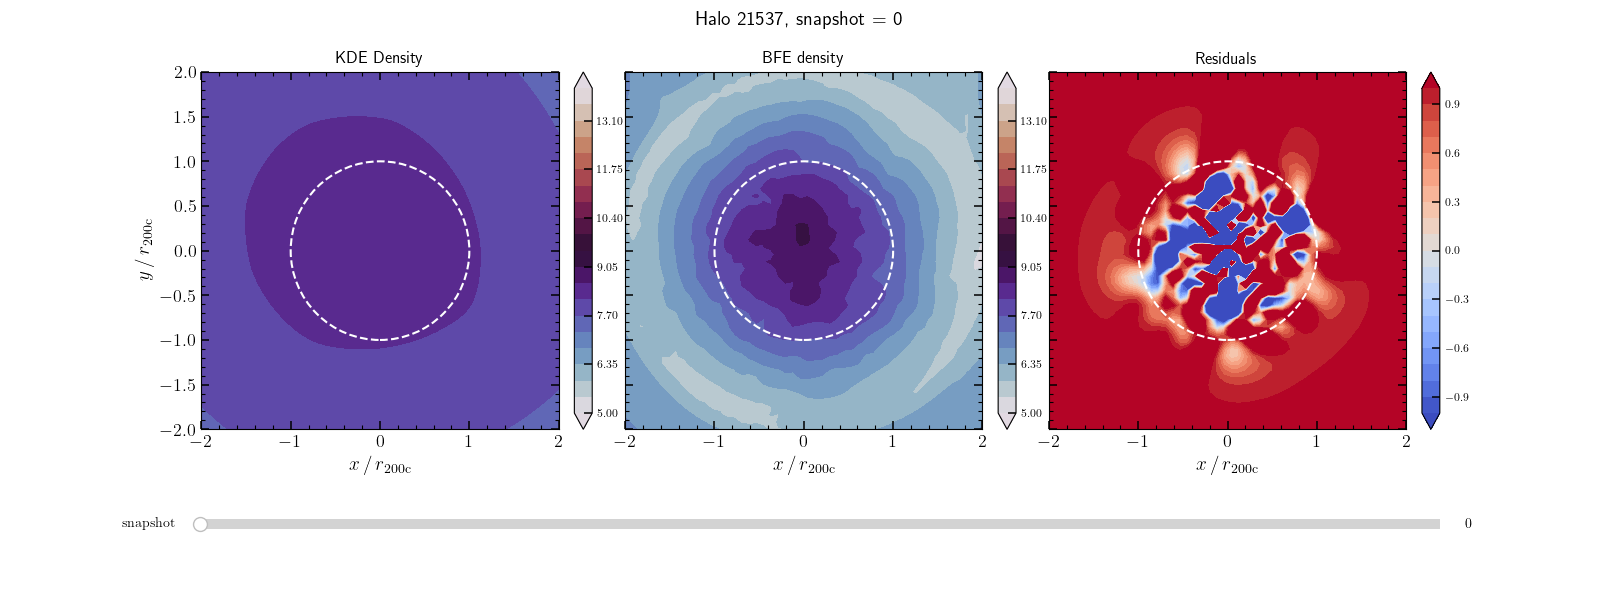

(<Figure size 1600x600 with 7 Axes>,
 [<Axes: title={'center': 'KDE Density'}, xlabel='$x\\,/\\,r_\\mathrm{200c}$', ylabel='$y\\,/\\,r_\\mathrm{200c}$'>,
  <Axes: title={'center': 'BFE density'}, xlabel='$x\\,/\\,r_\\mathrm{200c}$'>,
  <Axes: title={'center': 'Residuals'}, xlabel='$x\\,/\\,r_\\mathrm{200c}$'>],
 <matplotlib.widgets.Slider at 0x70085ed96f20>)

In [ ]:
visualize_4d_contour(
    np.log10(np.abs(kde_dens_4D)), 
    np.log10(np.abs(bfe_dens_4D)),
    np.array(MIRSE_4D),
    axis=2,
    cmaps=("twilight", "twilight", "coolwarm"),
    titles=("KDE Density", "BFE density", "Residuals"),
    coord_range=(-2.0, 2.0),
)